In [1]:
%env MUJOCO_GL=osmesa
import math
import os
import pathlib
import sys
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".15"

import numpy as np
import mediapy as media

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config

sys.path.append('../py_script')

env: MUJOCO_GL=osmesa


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


In [2]:
def _quat2axisangle(quat):
    """
    Copied from robosuite: https://github.com/ARISE-Initiative/robosuite/blob/eafb81f54ffc104f905ee48a16bb15f059176ad3/robosuite/utils/transform_utils.py#L490C1-L512C55
    """
    # clip quaternion
    if quat[3] > 1.0:
        quat[3] = 1.0
    elif quat[3] < -1.0:
        quat[3] = -1.0

    den = np.sqrt(1.0 - quat[3] * quat[3])
    if math.isclose(den, 0.0):
        # This is (close to) a zero degree rotation, immediately return
        return np.zeros(3)

    return (quat[:3] * 2.0 * math.acos(quat[3])) / den
    
# Load pi model
def create_pi05(model_name, checkpoint_dir=None, assets_dir=None):
    vla_config = _config.get_config(model_name)
    if checkpoint_dir is None:
        checkpoint_dir = download.maybe_download(f"gs://openpi-assets/checkpoints/{model_name}")
    else:
        checkpoint_dir = pathlib.Path(checkpoint_dir).resolve()

    # Load norm stats from assets dir if checkpoint doesn't have them
    norm_stats = None
    if assets_dir is not None:
        data_config = vla_config.data.create(vla_config.assets_dirs, vla_config.model)
        if data_config.asset_id is not None:
            from openpi.training import checkpoints as _checkpoints
            assets_path = pathlib.Path(assets_dir).resolve()
            norm_stats = _checkpoints.load_norm_stats(assets_path, data_config.asset_id)

    initial_scene_plan = {
        "Plan: TBD.\n"
        " What I have done: TBD.\n"  # Extra space here follows the original dataset formatting...
        "Now I need to do: TBD.\n"
    }
    policy = _policy_config.create_trained_reasoning_policy(
        vla_config,
        checkpoint_dir,
        norm_stats=norm_stats,
        initial_scene_plan=initial_scene_plan,
        sample_kwargs={
            "temperature": 0.0,
            "max_reasoning_steps": 256,
            "force_initial_reasoning": True
        }
    )
    return policy

def prompt_from_obs(obs, task, scene_plan=''):
    """Build observation dict for Pi0Fuse inference.

    The thought prefix must match the training format from cot_simple.json:
      "Instruction: <task>\\n<scene_plan>"
    A 1-element thought list triggers action-mode tokenization (BEGIN_OF_ACTION
    suffix), which prefill() strips before deciding to think or act.
    """
    state_vec = np.concatenate(
        (
            obs["robot0_eef_pos"],
            _quat2axisangle(obs["robot0_eef_quat"]),
            obs["robot0_gripper_qpos"],
        )
    )
    return {
        'observation/image': obs['agentview_image'][::-1, ::-1, :],
        'observation/wrist_image': obs['robot0_eye_in_hand_image'][::-1, ::-1, :],
        "observation/state": state_vec,
        'prompt': task,
    }

def infer_until_action(policy, prompt, max_think_rounds=8):
    """Query the policy until it returns actions (not a thinking response)."""
    result = policy.infer(prompt)
    think_round = 0
    while result.get("isthinking", False):
        think_round += 1
        print(f"[Thinking {think_round}] {result.get('thought', '')}")
        if think_round >= max_think_rounds:
            raise RuntimeError(
                f"Policy is still thinking after {max_think_rounds} rounds; "
                "aborting this rollout."
            )
        result = policy.infer(prompt)
    return result

In [3]:
# Create a trained policy.
policy = create_pi05(   # Use LoRA weights:
    'pi05_libero_reason_lora',
    checkpoint_dir='../pace/openpi/checkpoints/pi05_libero_reason_lora/pi05_libero_reason_lora/7999',
    # checkpoint_dir='../pace/openpi/checkpoints/pi05_libero_reason_lora/pi05_libero_reason_lora_save/30000',
    assets_dir='../pace/openpi/assets/pi05_libero_reason_lora'
    # 'pi05_libero_10_reason_lora',
    # checkpoint_dir='../pace/openpi/checkpoints/pi05_libero_10_reason_lora/pi05_libero_10_reason_lora/1500',
    # assets_dir='../pace/openpi/assets/pi05_libero_10_reason_lora'
)

ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/hppeng/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7aab8b622000> is already entered
/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-37' coro=<_async_in_context.<locals>.run_in_context() runni

In [4]:
def get_info(o):
    print(type(o), dir(o))

In [36]:
get_info(policy._model.PaliGemma.llm.layers['attn'])
print(list(policy._model.PaliGemma.llm.layers['mlp']))

<class 'dict'> ['__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__ne__', '__new__', '__or__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'pop', 'popitem', 'setdefault', 'update', 'values']
['gating_einsum', 'gating_einsum_lora_a', 'gating_einsum_lora_b', 'linear', 'linear_lora_a', 'linear_lora_b']


In [4]:
def _get_libero_env(task, resolution, seed):
    """Initializes and returns the LIBERO environment, along with the task description."""
    task_description = task.language
    task_bddl_file = pathlib.Path(get_libero_path("bddl_files")) / task.problem_folder / task.bddl_file
    env_args = {"bddl_file_name": task_bddl_file, "camera_heights": resolution, "camera_widths": resolution, "camera_depths": True}
    env = OffScreenRenderEnv(**env_args)
    env.seed(seed)  # IMPORTANT: seed seems to affect object positions even when using fixed initial state
    return env, task_description

class LiberoEnvMaker:
    def __init__(self, suite: str,
                 render_resolution: int = 512, seed: int = 0,
                 repeats: int = 1):
        benchmark_dict = benchmark.get_benchmark_dict()
        self.task_suite = benchmark_dict[suite]()
        self.repeats = repeats
        self.render_resolution = render_resolution
        self.seed = seed

    def get_num_tasks(self):
        return self.task_suite.n_tasks

    def task_instantiations(self, task_id):
        task = self.task_suite.get_task(task_id)
        initial_states = self.task_suite.get_task_init_states(task_id)
        env, task_description = _get_libero_env(task, self.render_resolution, self.seed)
        for episode_idx in range(self.repeats):
            env.reset()
            obs = env.set_init_state(initial_states[episode_idx])
            yield obs, env, task_description

libero_envs = LiberoEnvMaker('libero_90')

prefill EOP (act, reason): -18.375, -20.5
mode thinking now...


/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/flax/core/scope.py:959: DeprecationWarning: shape requires ndarray or scalar arguments, got <class 'jax._src.api.ShapeDtypeStruct'> at position 0. In a future JAX release this will be an error.
  if jnp.shape(val) != jnp.shape(abs_val):
/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/flax/core/scope.py:959: DeprecationWarning: shape requires ndarray or scalar arguments, got <class 'jax._src.api.ShapeDtypeStruc

[Thinking 1] Plan: 1. Close the top drawer of the cabinet. What I have done: Subtask: Subtask: close the top drawer
prefill EOP (act, reason): -13.125, -15.875
mode acting now...


/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/flax/core/scope.py:959: DeprecationWarning: shape requires ndarray or scalar arguments, got <class 'jax._src.api.ShapeDtypeStruct'> at position 0. In a future JAX release this will be an error.
  if jnp.shape(val) != jnp.shape(abs_val):
/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/flax/core/scope.py:959: DeprecationWarning: shape requires ndarray or scalar arguments, got <class 'jax._src.api.ShapeDtypeStruc

Subtask: Plan: 1. Close the top drawer of the cabinet. What I have done: Subtask: Subtask: close the top drawer
prefill EOP (act, reason): -10.0625, -12.875
mode acting now...
Subtask: Plan: 1. Close the top drawer of the cabinet. What I have done: Subtask: Subtask: close the top drawer
prefill EOP (act, reason): -7.34375, -10.0625
mode acting now...
Subtask: Plan: 1. Close the top drawer of the cabinet. What I have done: Subtask: Subtask: close the top drawer
prefill EOP (act, reason): -13.25, -15.5
mode acting now...
Subtask: Plan: 1. Close the top drawer of the cabinet. What I have done: Subtask: Subtask: close the top drawer
prefill EOP (act, reason): -15.5, -17.75
mode acting now...
Subtask: Plan: 1. Close the top drawer of the cabinet. What I have done: Subtask: Subtask: close the top drawer
prefill EOP (act, reason): -18.375, -20.75
mode acting now...
Subtask: Plan: 1. Close the top drawer of the cabinet. What I have done: Subtask: Subtask: close the top drawer
prefill EOP (act,

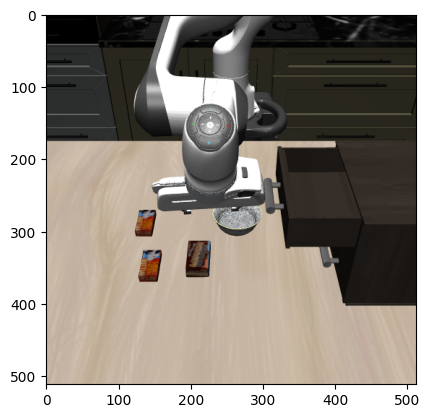

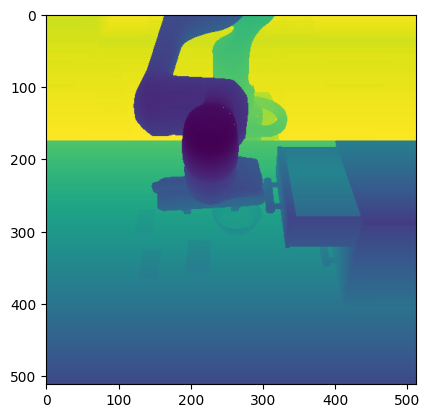

In [6]:
# rollout = []
# frames = []
# wrist_frames = []
# snapshots = []
# statuses = []
# subtasks = []

def get_cam_pose(env, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    return (env.sim.model.cam_pos[cam_id], env.sim.model.cam_quat[cam_id])
    
def set_cam_pose(env, pose, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    env.sim.model.cam_pos[cam_id] = pose[0]
    env.sim.model.cam_quat[cam_id] = pose[1]

for instance in libero_envs.task_instantiations(0):
    obs, env, task_description = instance
    #task_description = "Close the drawer"
    #task_description = "Open the top top drawer."
    #task_description = 'Pick up the black bowl.'
    # prev_pos, prev_quat = save_cam_pose
    # set_cam_pose(env, (prev_pos+[0, 0, 1], prev_quat))
    # obs, reward, done, info = env.step(np.zeros(7))
    # break
    #scene_plan = 'Plan: 1. Pick up the cookie box. What have I done: 1. Pick up the cookie box. Now I need to do: Nothing. Task complete.'
    #scene_plan = ''
    #scene_plan = 'Plan: 1. Open the top drawer. \
#What have I done: Open the top drawer. \
#Now I need to do: Nothing. Task complete.'
    prompt = prompt_from_obs(obs, task_description)
    vla_output = infer_until_action(policy, prompt)
    actions = vla_output['actions']
    subtask = vla_output.get('subtask', None)
    if subtask is not None:
        print("Subtask:", subtask)
        scene_plan = subtask
    rollout.append(obs)

    trajectory_idx = 0
    for i in range(50):
        act = np.copy(actions[trajectory_idx])
        act[-1] *= 1
        obs, reward, done, info = env.step(act)
        rollout.append(obs)
        frames.append(obs['agentview_image'][::-1, ::-1, :])
        wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
        trajectory_idx += 1
        if trajectory_idx == (len(actions)//2):
            prompt = prompt_from_obs(obs, task_description)
            vla_output = infer_until_action(policy, prompt)
            actions = vla_output['actions']
            subtask = vla_output.get('subtask', None)
            if subtask is not None:
                print("Subtask:", subtask)
                scene_plan = subtask
            trajectory_idx = 0

freq = 20
#save_cam_pose = get_cam_pose(env)
print(task_description)
img = obs['agentview_image'][::-1, ::-1, :]
import matplotlib.pyplot as plt
plt.figure(0)
plt.clf()
plt.imshow(img)
plt.figure(1)
plt.clf()
plt.imshow(obs['agentview_depth'][::-1, ::-1, :])
plt.show()
media.write_video(f'franka_90.mp4', frames, fps=freq)
media.write_video(f'franka_90_wrist.mp4', wrist_frames, fps=freq)
media.write_video(f'franka_libero.mp4', frames, fps=freq)
media.write_video(f'franka_libero_wrist.mp4', wrist_frames, fps=freq)